# Machine Learning - Session 3

## `LinearRegression`

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
X = np.array([[1, 1], [1, 2], [2, 2], [2, 3]])
# y = 1 * x_0 + 2 * x_1 + 3
y = np.dot(X, np.array([1, 2])) + 3

In [ ]:
reg = LinearRegression().fit(X, y)

In [6]:
reg.score(X, y)

1.0

In [7]:
reg.coef_

array([1., 2.])

In [8]:
reg.intercept_

np.float64(3.0000000000000018)

In [9]:
reg.predict(np.array([[3, 5]]))

array([16.])

## `SGDRegressor`

-- Epoch 1
Norm: 0.06, NNZs: 5, Bias: 0.072345, T: 10, Avg. loss: 0.736503, Objective: 0.736503
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 0.12, NNZs: 5, Bias: 0.137423, T: 10, Avg. loss: 0.650575, Objective: 0.650575
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 0.16, NNZs: 5, Bias: 0.195982, T: 10, Avg. loss: 0.582649, Objective: 0.582649
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 0.21, NNZs: 5, Bias: 0.248690, T: 10, Avg. loss: 0.528389, Objective: 0.528389
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 0.24, NNZs: 5, Bias: 0.296143, T: 10, Avg. loss: 0.484596, Objective: 0.484596
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 0.28, NNZs: 5, Bias: 0.338877, T: 10, Avg. loss: 0.448887, Objective: 0.448887
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 0.31, NNZs: 5, Bias: 0.377369, T: 10, Avg. loss: 0.419477, Objective: 0.419477
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 0.34, NNZs: 5, Bias: 0.412048, T: 10, Avg. loss: 0.395012, Objecti

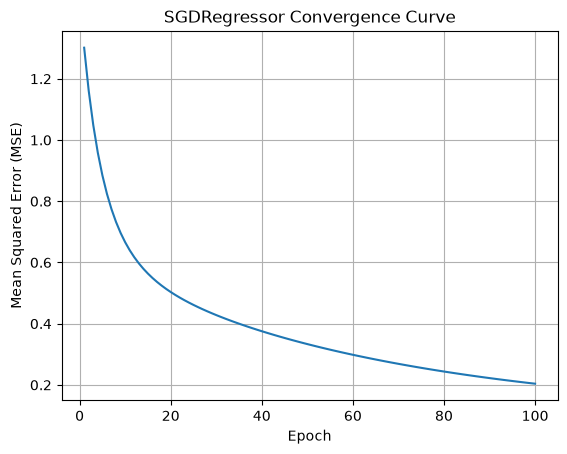

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

n_samples, n_features = 10, 5
rng = np.random.RandomState(0)
y = rng.randn(n_samples)
X = rng.randn(n_samples, n_features)

# 1. Scaling features is mandatory for SGD
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Initialize SGDRegressor
model = SGDRegressor(
    loss="squared_error",
    penalty=None,          # Pure linear regression (no L2/L1 penalty)
    learning_rate="constant",
    eta0=0.01,             # Learning rate alpha
    random_state=42,
    max_iter=1000, tol=1e-3, verbose=1
)

# 3. Train epoch-by-epoch and track loss
epochs = 100
loss_curve = []

for epoch in range(epochs):
    # Perform one pass over the data
    model.partial_fit(X_scaled, y)
    
    # Calculate current Mean Squared Error
    y_pred = model.predict(X_scaled)
    current_loss = mean_squared_error(y, y_pred)
    loss_curve.append(current_loss)

# 4. Plot the recorded loss curve
plt.plot(range(1, epochs + 1), loss_curve)
plt.title("SGDRegressor Convergence Curve")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True)
plt.show()

## `LogisticRegression`

In [31]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
X, y = load_iris(return_X_y=True)
print(X.shape, y.shape)

(150, 4) (150,)


In [32]:
clf = LogisticRegression(random_state=0).fit(X, y)
sample_index_min = 40
sample_index_max = 400
clf.predict(X[sample_index_min:sample_index_max, :])

/home/mylo2202/Projects/fsb-mle/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [33]:
clf.predict_proba(X[sample_index_min:sample_index_max, :])

array([[9.86615392e-01, 1.33845968e-02, 1.13615033e-08],
       [9.62215550e-01, 3.77843837e-02, 6.62638253e-08],
       [9.88997409e-01, 1.10025802e-02, 1.12719526e-08],
       [9.72425990e-01, 2.75738721e-02, 1.37385932e-07],
       [9.60208281e-01, 3.97914962e-02, 2.22422184e-07],
       [9.73848687e-01, 2.61512735e-02, 4.00077088e-08],
       [9.80296611e-01, 1.97033633e-02, 2.52745751e-08],
       [9.83321975e-01, 1.66780052e-02, 2.01277460e-08],
       [9.78572226e-01, 2.14277550e-02, 1.86747997e-08],
       [9.78660588e-01, 2.13393930e-02, 1.92662240e-08],
       [2.12069793e-03, 8.74027007e-01, 1.23852295e-01],
       [5.78174660e-03, 8.59777575e-01, 1.34440679e-01],
       [1.05546896e-03, 7.25184051e-01, 2.73760480e-01],
       [1.53569311e-02, 9.39294382e-01, 4.53486864e-02],
       [2.36656791e-03, 8.14535746e-01, 1.83097686e-01],
       [6.91701079e-03, 8.60178079e-01, 1.32904910e-01],
       [3.73696232e-03, 7.17057899e-01, 2.79205139e-01],
       [1.47462733e-01, 8.49451

In [34]:
clf.score(X, y)

0.9733333333333334